In [1]:
import sys
from pathlib import Path

import folium
import pandas as pd
from folium.raster_layers import ImageOverlay

# Insert repo root directory into notebook path to allow for import with the repo directory
repository_root = Path.cwd().parent.parent.resolve()
sys.path.insert(0, str(repository_root))

from land_cover_change.app.components.map_legend import (
    build_dynamic_world_legend,
)
from land_cover_change.config.config import resolved_config
from land_cover_change.data_access.raster import (
    discover_lulc_rasters,
    extract_raster_map_metadata,
)
from land_cover_change.data_access.vector import load_vector_data
from land_cover_change.services.class_area import build_class_count_table
from land_cover_change.services.raster import prepare_map_overlay

In [2]:
# Discover and validate the configured Dynamic World raster inputs.
lulc_directory_path = Path(
    resolved_config.dataset.raw_dataset.aoi_lulc
)
lulc_raster_paths = discover_lulc_rasters(lulc_directory_path)

# Load the AOI used to clip the Dynamic World rasters.
aoi_path = Path(resolved_config.dataset.raw_dataset.aoi_geojson)
aoi = load_vector_data(aoi_path)

# Derive labels and colours from the authoritative class registry.
dynamic_world_classes = resolved_config.dynamic_world.classes
dynamic_world_palette = {
    class_value: class_definition.colour
    for class_value, class_definition in dynamic_world_classes.items()
}

In [3]:
# Inspect the metadata of every discovered raster.
raster_metadata_table = pd.DataFrame(
    [
        {
            "raster_name": raster_path.name,
            **extract_raster_map_metadata(raster_path),
        }
        for raster_path in lulc_raster_paths
    ]
).set_index("raster_name")

raster_metadata_table

,coordinate_reference_system,shape,resolution,bounds,band_count,data_types,transform,nodata
raster_name,,,,,,,,
lulc_2016_jan_feb.tif,"(proj, datum, no_defs)","(950, 1053)","(8.983152841195215e-05, 8.983152841195215e-05)","(5.638725038418237, 6.368875701350584, 5.73331...",1,"(uint8,)","(8.983152841195215e-05, 0.0, 5.638725038418237...",255.0
lulc_2020_jan_feb.tif,"(proj, datum, no_defs)","(950, 1053)","(8.983152841195215e-05, 8.983152841195215e-05)","(5.638725038418237, 6.368875701350584, 5.73331...",1,"(uint8,)","(8.983152841195215e-05, 0.0, 5.638725038418237...",255.0
lulc_2025_jan_feb.tif,"(proj, datum, no_defs)","(950, 1053)","(8.983152841195215e-05, 8.983152841195215e-05)","(5.638725038418237, 6.368875701350584, 5.73331...",1,"(uint8,)","(8.983152841195215e-05, 0.0, 5.638725038418237...",255.0


In [ ]:
# Build a dynamic pixel-count table and include classes absent from all years.
class_count_table = (
    build_class_count_table(lulc_raster_paths)
    .set_index("class_value")
    .reindex(dynamic_world_classes, fill_value=0)    # type:ignore
    .reset_index()
)

class_names = {
    class_value: class_definition.name
    for class_value, class_definition in dynamic_world_classes.items()
}
class_count_table.insert(
    1,
    "class_name",
    class_count_table["class_value"].map(class_names),
)

class_count_table

,class_value,class_name,lulc_2016_jan_feb.tif,lulc_2020_jan_feb.tif,lulc_2025_jan_feb.tif
0,0,water,738,322,232
1,1,trees,314203,252006,119004
2,2,grass,783,47,534
3,3,flooded vegetation,446,216,0
4,4,crops,3483,23674,2388
5,5,shrub and scrub,39188,45527,94337
6,6,built area,224004,256573,368448
7,7,bare ground,2098,6578,0
8,8,snow and ice,0,0,0


In [5]:
# Reproject and colourise every raster for an OpenStreetMap overlay.
map_overlays = {
    raster_path.name: prepare_map_overlay(
        raster_path,
        dynamic_world_palette,
    )
    for raster_path in lulc_raster_paths
}

overlay_summary = pd.DataFrame(
    [
        {
            "raster_name": raster_name,
            "rgba_shape": overlay.image.shape,
            "folium_bounds": overlay.bounds,
        }
        for raster_name, overlay in map_overlays.items()
    ]
).set_index("raster_name")

overlay_summary

,rgba_shape,folium_bounds
raster_name,,
lulc_2016_jan_feb.tif,"(953, 1050, 4)","((6.368900984239045, 5.638725038418237), (6.45..."
lulc_2020_jan_feb.tif,"(953, 1050, 4)","((6.368900984239045, 5.638725038418237), (6.45..."
lulc_2025_jan_feb.tif,"(953, 1050, 4)","((6.368900984239045, 5.638725038418237), (6.45..."



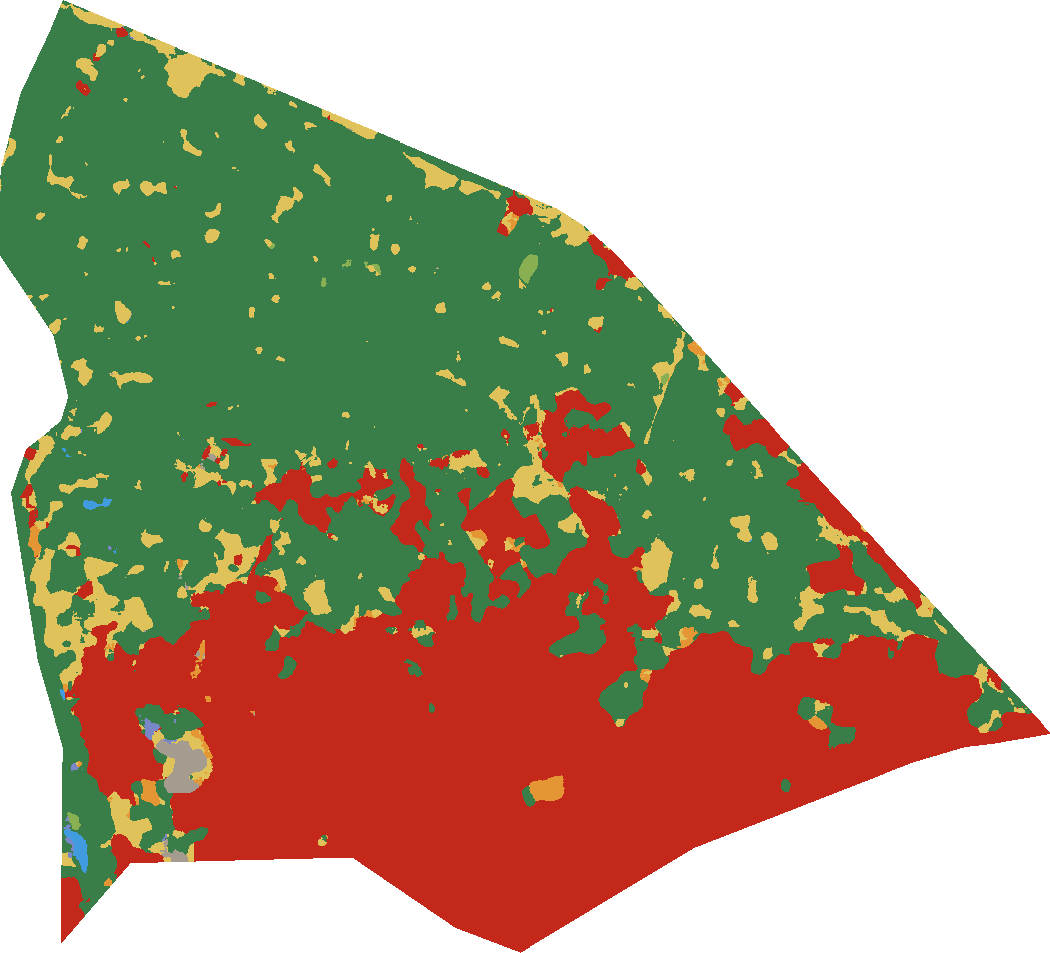
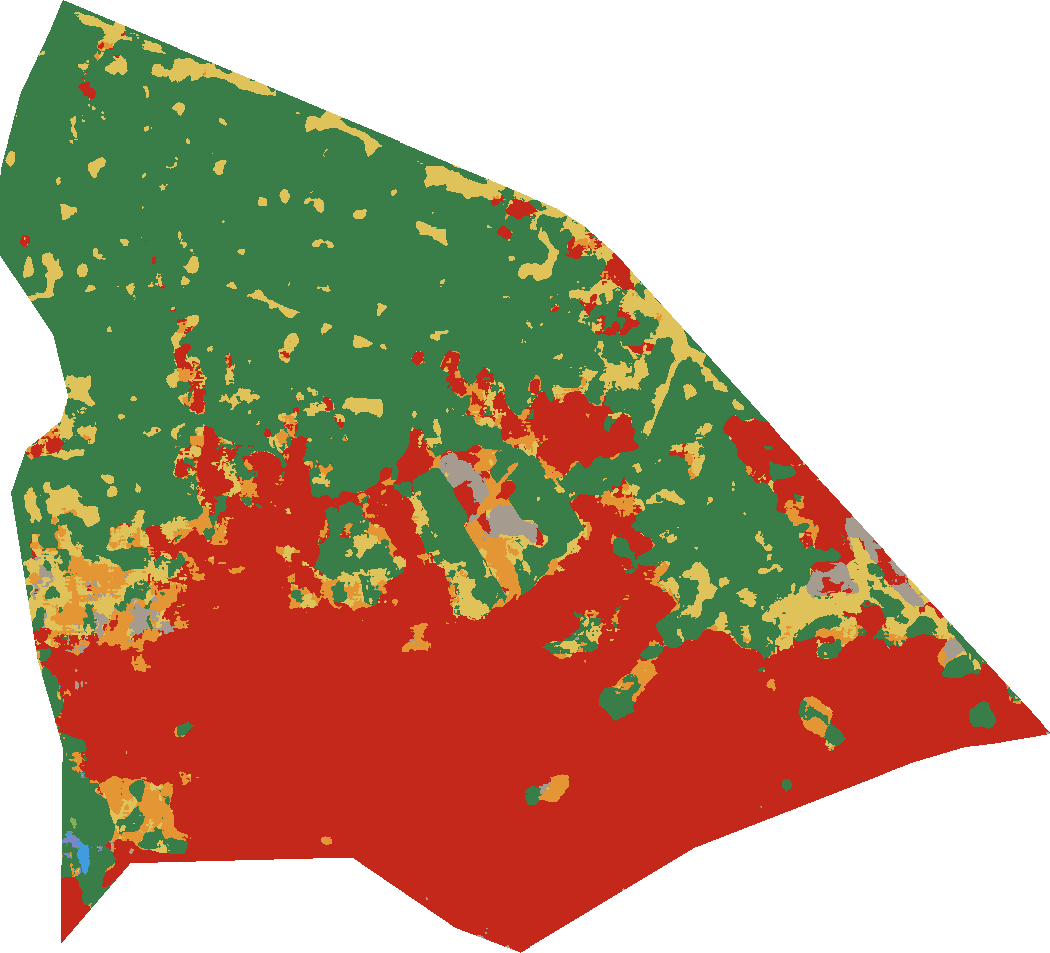
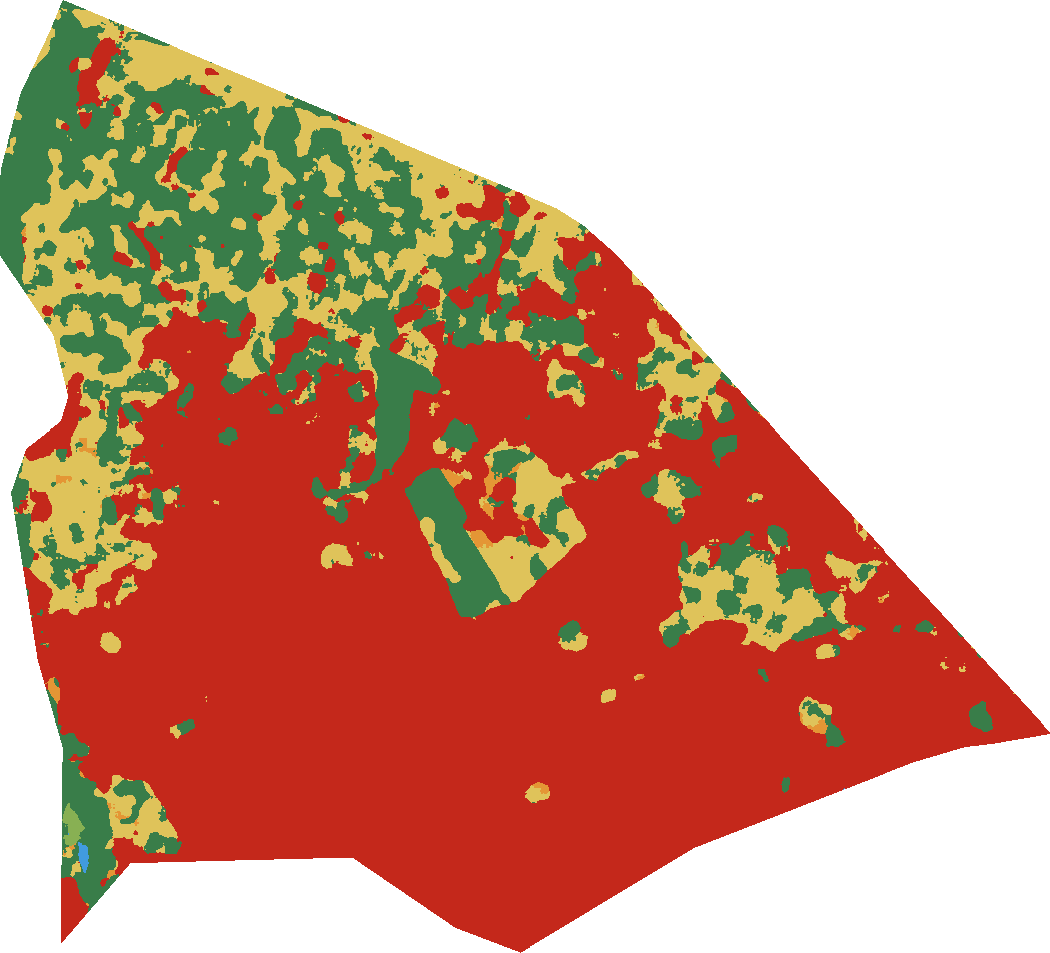

In [6]:
# Build one interactive map with selectable annual raster overlays.
south = min(overlay.bounds[0][0] for overlay in map_overlays.values())
west = min(overlay.bounds[0][1] for overlay in map_overlays.values())
north = max(overlay.bounds[1][0] for overlay in map_overlays.values())
east = max(overlay.bounds[1][1] for overlay in map_overlays.values())
map_bounds = ((south, west), (north, east))

dynamic_world_map = folium.Map(
    location=[(south + north) / 2, (west + east) / 2],
    tiles="OpenStreetMap",
    control_scale=True,
)

for raster_index, raster_path in enumerate(lulc_raster_paths):
    overlay = map_overlays[raster_path.name]
    ImageOverlay(
        image=overlay.image,
        bounds=overlay.bounds,
        name=raster_path.stem.replace("_", " ").title(),
        opacity=0.7,
        origin="upper",
        pixelated=True,
        show=raster_index == len(lulc_raster_paths) - 1,
    ).add_to(dynamic_world_map)

folium.GeoJson(
    data=aoi.to_crs("EPSG:4326").__geo_interface__,
    name="Area of interest",
    style_function=lambda _: {
        "color": "#111827",
        "weight": 2,
        "fillOpacity": 0,
    },
).add_to(dynamic_world_map)

build_dynamic_world_legend(dynamic_world_classes).add_to(
    dynamic_world_map
)
folium.LayerControl(collapsed=False).add_to(dynamic_world_map)
dynamic_world_map.fit_bounds(map_bounds)

dynamic_world_map